# Mini-Reasoner z Test-Time Compute
### Porównanie strategii inferencji na zbiorze GSM8K

Notebook testuje kilka strategii zwiększania jakości odpowiedzi modelu językowego bez zmiany wag modelu.
Model bazowy: `Qwen/Qwen2.5-1.5B-Instruct` (oraz wariant AWQ do porównania wydajności).

**Serwer vLLM musi być uruchomiony przed wykonaniem komórek testowych.**

Komenda do uruchomienia zwykłego modelu:
```
vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --dtype auto
```
Komenda do uruchomienia modelu AWQ (po restarcie):
```
vllm serve Qwen/Qwen2.5-1.5B-Instruct-AWQ --port 8000
```

## 1. Instalacja zależności

In [1]:
!pip install vllm transformers torch datasets pandas matplotlib requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of cuda-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.4/244.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 70.5 

## 2. Przygotowanie danych

Pobieramy 100 zadań ze zbioru GSM8K (test split). Każde zadanie to pytanie matematyczne
z rozwiązaniem krok po kroku. Odpowiedź docelową wyciągamy po znaczniku `####`.

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

ds = load_dataset("openai/gsm8k", "main", split="test")
subset = ds.select(range(100))

data = []
for s in subset:
    answer = s["answer"].split("#### ")[-1].strip()
    # usuwamy przecinki z liczb typu 1,000 -> 1000
    data.append({"question": s["question"], "target": answer})

df_data = pd.DataFrame(data)
print(f"Załadowano {len(data)} zadań")
df_data.head(10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Załadowano 100 zadań


,question,target
0,Janet’s ducks lay 16 eggs per day. She eats th...,18
1,A robe takes 2 bolts of blue fiber and half th...,3
2,Josh decides to try flipping a house. He buys...,70000
3,James decides to run 3 sprints 3 times a week....,540
4,"Every day, Wendi feeds each of her chickens th...",20


## 3. Funkcje pomocnicze

Wspólne narzędzia używane przez wszystkie strategie — wyciąganie liczby z tekstu
i normalizacja do porównania z odpowiedzią docelową.

In [2]:
import re
import requests
import time
import csv
import os
from collections import Counter

VLLM_URL = "http://localhost:8000/v1/chat/completions"
LOG_FILE = "experiment_results.csv"


def extract_number(text):
    """
    Próbuje wyciągnąć liczbę z odpowiedzi modelu.
    Najpierw szuka frazy 'Final answer: X', potem bierze ostatnią liczbę z tekstu.
    """
    # szukamy frazy Final answer: <liczba>
    fa = re.search(r"[Ff]inal\s+answer\s*[:\-]?\s*([\d,\.]+)", text)
    if fa:
        return fa.group(1).replace(",", "")
    # fallback - ostatnia liczba w tekście
    nums = re.findall(r"[-+]?\d[\d,]*\.?\d*", text)
    return nums[-1].replace(",", "") if nums else None


def normalize(s):
    """
    Normalizuje odpowiedź do floata żeby uniknąć błędów np. '4' != '4.0'.
    """
    if s is None:
        return ""
    try:
        return str(float(str(s).replace(",", "")))
    except ValueError:
        return str(s).strip()


def is_correct(pred, target):
    return normalize(pred) == normalize(target)


def save_result(strategy, model, accuracy, duration, total_tokens):
    """
    Dopisuje wynik do pliku CSV. Tworzy plik jeśli nie istnieje.
    """
    throughput = round(total_tokens / duration, 1) if duration > 0 else 0
    file_exists = os.path.isfile(LOG_FILE)
    with open(LOG_FILE, mode="a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["Timestamp", "Strategy", "Model",
                             "Accuracy (%)", "Duration (s)",
                             "Total Tokens", "Throughput (tok/s)"])
        writer.writerow([
            time.strftime("%Y-%m-%d %H:%M:%S"),
            strategy, model,
            round(accuracy, 2),
            round(duration, 2),
            total_tokens,
            throughput
        ])
    print(f"  Zapisano do {LOG_FILE}")


def call_model(model, messages, temperature=0, max_tokens=512, n=1):
    """
    Wysyła zapytanie do serwera vLLM. Zwraca odpowiedź lub None przy błędzie.
    """
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
        "n": n
    }
    try:
        resp = requests.post(VLLM_URL, json=payload, timeout=60)
        resp.raise_for_status()
        return resp.json()
    except Exception as e:
        print(f"    [błąd zapytania] {e}")
        return None


print("Funkcje pomocnicze załadowane.")

Funkcje pomocnicze załadowane.


---
# CZĘŚĆ 1 — Model: Qwen2.5-1.5B-Instruct (bez kwantyzacji)

**Przed uruchomieniem tej sekcji uruchom serwer:**
```
vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --dtype auto
```

### 1A. Baseline (greedy decoding)

In [3]:
MODEL_BASE = "Qwen/Qwen2.5-1.5B-Instruct"

correct_count = 0
total_tokens = 0
results_baseline = []
t_start = time.time()

print("Uruchamiam Baseline...")

for i, task in enumerate(data):
    messages = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_BASE, messages, temperature=0, max_tokens=512)

    pred = None
    comp_tokens = 0
    if resp:
        output = resp["choices"][0]["message"]["content"]
        comp_tokens = resp.get("usage", {}).get("completion_tokens", 0)
        pred = extract_number(output)
        total_tokens += comp_tokens

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_baseline.append({"id": i, "pred": pred, "target": task["target"],
                               "correct": correct, "tokens": comp_tokens})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_baseline = time.time() - t_start
acc_baseline = correct_count / len(data) * 100

print(f"\nBaseline Accuracy: {acc_baseline:.1f}%")
print(f"Czas: {t_baseline:.1f}s | Tokeny: {total_tokens}")
save_result("Baseline", MODEL_BASE, acc_baseline, t_baseline, total_tokens)

Uruchamiam Baseline...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Baseline Accuracy: 63.0%
Czas: 501.5s | Tokeny: 30420
  Zapisano do experiment_results.csv


### 1B. Majority Vote (Self-Consistency, n=10)

In [4]:
correct_count = 0
total_tokens = 0
results_mv = []
t_start = time.time()

print("Uruchamiam Majority Vote (n=10)...")

for i, task in enumerate(data):
    messages = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_BASE, messages, temperature=0.7, max_tokens=512, n=10)

    pred = None
    if resp:
        total_tokens += resp.get("usage", {}).get("completion_tokens", 0)
        candidates = []
        for choice in resp["choices"]:
            num = extract_number(choice["message"]["content"])
            if num:
                candidates.append(normalize(num))
        if candidates:
            pred = Counter(candidates).most_common(1)[0][0]

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_mv.append({"id": i, "pred": pred, "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_mv = time.time() - t_start
acc_mv = correct_count / len(data) * 100

print(f"\nMajority Vote Accuracy: {acc_mv:.1f}%")
print(f"Czas: {t_mv:.1f}s | Tokeny: {total_tokens}")
save_result("Majority Vote", MODEL_BASE, acc_mv, t_mv, total_tokens)

Uruchamiam Majority Vote (n=10)...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Majority Vote Accuracy: 75.0%
Czas: 691.6s | Tokeny: 287344
  Zapisano do experiment_results.csv


### 1C. Self-Refine

Model generuje odpowiedź, a następnie dostaje ją z powrotem z prośbą o sprawdzenie błędów.

In [5]:
correct_count = 0
total_tokens = 0
results_sr = []
t_start = time.time()

print("Uruchamiam Self-Refine...")

for i, task in enumerate(data):
    # krok 1: pierwsza odpowiedź
    messages1 = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp1 = call_model(MODEL_BASE, messages1, temperature=0, max_tokens=512)

    pred = None
    if resp1:
        initial = resp1["choices"][0]["message"]["content"]
        total_tokens += resp1.get("usage", {}).get("completion_tokens", 0)

        # krok 2: weryfikacja
        refine_msg = (
            f"Problem: {task['question']}\n\n"
            f"Your solution: {initial}\n\n"
            "Check every calculation step carefully. If you find a mistake, correct it. "
            "End with: Final answer: <number>"
        )
        messages2 = [
            {"role": "system", "content": "You are a careful math checker."},
            {"role": "user",   "content": refine_msg}
        ]
        resp2 = call_model(MODEL_BASE, messages2, temperature=0, max_tokens=512)

        if resp2:
            final = resp2["choices"][0]["message"]["content"]
            total_tokens += resp2.get("usage", {}).get("completion_tokens", 0)
            pred = extract_number(final)
        else:
            pred = extract_number(initial)

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_sr.append({"id": i, "pred": pred, "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_sr = time.time() - t_start
acc_sr = correct_count / len(data) * 100

print(f"\nSelf-Refine Accuracy: {acc_sr:.1f}%")
print(f"Czas: {t_sr:.1f}s | Tokeny: {total_tokens}")
save_result("Self-Refine", MODEL_BASE, acc_sr, t_sr, total_tokens)

Uruchamiam Self-Refine...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Self-Refine Accuracy: 63.0%
Czas: 823.4s | Tokeny: 49102
  Zapisano do experiment_results.csv


### 1D. Prompt Routing

Przed wysłaniem zapytania do modelu klasyfikujemy zadanie na podstawie słów kluczowych
i dobieramy prompt specyficzny dla danego typu. Małe modele są bardzo wrażliwe na
sformułowanie instrukcji, więc dopasowanie promptu do struktury zadania ma realny wpływ na wyniki.

Kategorie: `percentage`, `rate_time`, `multi_step`, `comparison`, `default`.

In [6]:
# szablony promptów per typ zadania
PROMPT_TEMPLATES = {
    "percentage": (
        "You are solving a percentage problem. Steps: "
        "1) identify the base value, 2) find the percentage amount, 3) compute the result. "
        "End with: Final answer: <number>"
    ),
    "rate_time": (
        "You are solving a rate/speed/time problem. "
        "Use distance = speed × time or its variants. "
        "End with: Final answer: <number>"
    ),
    "multi_step": (
        "This problem has multiple steps. Number each sub-problem, solve them in order, "
        "then combine results. End with: Final answer: <number>"
    ),
    "comparison": (
        "You are solving a comparison problem. "
        "Compute each quantity separately, then find the difference or ratio. "
        "End with: Final answer: <number>"
    ),
    "default": (
        "Solve the math problem step by step. End with: Final answer: <number>"
    ),
}

ROUTING_RULES = [
    ("percentage", re.compile(r"\b(percent|%|discount|tax|interest|markup|tip)\b", re.I)),
    ("rate_time",  re.compile(r"\b(speed|mph|km/h|per hour|per minute|rate|travel|distance)\b", re.I)),
    ("multi_step", re.compile(r"\b(first|then|after(ward)?|finally|next|subsequently)\b", re.I)),
    ("comparison", re.compile(r"\b(more than|less than|difference|ratio|how many more|how much more)\b", re.I)),
]

def classify_task(question):
    for category, pattern in ROUTING_RULES:
        if pattern.search(question):
            return category
    return "default"


correct_count = 0
total_tokens = 0
results_pr = []
category_stats = {}
t_start = time.time()

print("Uruchamiam Prompt Routing...")

for i, task in enumerate(data):
    category = classify_task(task["question"])

    messages = [
        {"role": "system", "content": PROMPT_TEMPLATES[category]},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_BASE, messages, temperature=0, max_tokens=512)

    pred = None
    if resp:
        output = resp["choices"][0]["message"]["content"]
        total_tokens += resp.get("usage", {}).get("completion_tokens", 0)
        pred = extract_number(output)

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    if category not in category_stats:
        category_stats[category] = {"total": 0, "correct": 0}
    category_stats[category]["total"] += 1
    category_stats[category]["correct"] += int(correct)

    results_pr.append({"id": i, "category": category, "pred": pred,
                        "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_pr = time.time() - t_start
acc_pr = correct_count / len(data) * 100

print(f"\nPrompt Routing Accuracy: {acc_pr:.1f}%")
print(f"Czas: {t_pr:.1f}s | Tokeny: {total_tokens}")
print("\nWyniki per kategoria:")
for cat, stats in sorted(category_stats.items()):
    cat_acc = stats["correct"] / stats["total"] * 100
    print(f"  {cat:<14}: {stats['correct']}/{stats['total']} ({cat_acc:.0f}%)")

save_result("Prompt Routing", MODEL_BASE, acc_pr, t_pr, total_tokens)

Uruchamiam Prompt Routing...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Prompt Routing Accuracy: 70.0%
Czas: 495.2s | Tokeny: 29986

Wyniki per kategoria:
  comparison    : 9/10 (90%)
  default       : 37/52 (71%)
  multi_step    : 18/24 (75%)
  percentage    : 2/4 (50%)
  rate_time     : 4/10 (40%)
  Zapisano do experiment_results.csv


---
# CZĘŚĆ 2 — Model: Qwen2.5-1.5B-Instruct-AWQ (kwantyzacja)

**Przed uruchomieniem tej sekcji zrestartuj serwer vLLM:**
```
vllm serve Qwen/Qwen2.5-1.5B-Instruct-AWQ --port 8000
```
Cel tej sekcji to pomiar throughput przy kwantyzacji i porównanie z modelem bez kwantyzacji.

### 2A. Baseline AWQ

In [8]:
MODEL_AWQ = "Qwen/Qwen2.5-1.5B-Instruct-AWQ"

correct_count = 0
total_tokens = 0
results_baseline_awq = []
t_start = time.time()

print("Uruchamiam Baseline AWQ...")

for i, task in enumerate(data):
    messages = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_AWQ, messages, temperature=0, max_tokens=512)

    pred = None
    comp_tokens = 0
    if resp:
        output = resp["choices"][0]["message"]["content"]
        comp_tokens = resp.get("usage", {}).get("completion_tokens", 0)
        pred = extract_number(output)
        total_tokens += comp_tokens

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_baseline_awq.append({"id": i, "pred": pred, "target": task["target"],
                                   "correct": correct, "tokens": comp_tokens})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_baseline_awq = time.time() - t_start
acc_baseline_awq = correct_count / len(data) * 100

print(f"\nBaseline AWQ Accuracy: {acc_baseline_awq:.1f}%")
print(f"Czas: {t_baseline_awq:.1f}s | Tokeny: {total_tokens}")
save_result("Baseline", MODEL_AWQ, acc_baseline_awq, t_baseline_awq, total_tokens)

Uruchamiam Baseline AWQ...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Baseline AWQ Accuracy: 64.0%
Czas: 243.2s | Tokeny: 29505
  Zapisano do experiment_results.csv


### 2B. Majority Vote AWQ

In [9]:
correct_count = 0
total_tokens = 0
results_mv_awq = []
t_start = time.time()

print("Uruchamiam Majority Vote AWQ (n=10)...")

for i, task in enumerate(data):
    messages = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_AWQ, messages, temperature=0.7, max_tokens=512, n=10)

    pred = None
    if resp:
        total_tokens += resp.get("usage", {}).get("completion_tokens", 0)
        candidates = []
        for choice in resp["choices"]:
            num = extract_number(choice["message"]["content"])
            if num:
                candidates.append(normalize(num))
        if candidates:
            pred = Counter(candidates).most_common(1)[0][0]

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_mv_awq.append({"id": i, "pred": pred, "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_mv_awq = time.time() - t_start
acc_mv_awq = correct_count / len(data) * 100

print(f"\nMajority Vote AWQ Accuracy: {acc_mv_awq:.1f}%")
print(f"Czas: {t_mv_awq:.1f}s | Tokeny: {total_tokens}")
save_result("Majority Vote", MODEL_AWQ, acc_mv_awq, t_mv_awq, total_tokens)

Uruchamiam Majority Vote AWQ (n=10)...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Majority Vote AWQ Accuracy: 73.0%
Czas: 403.1s | Tokeny: 294046
  Zapisano do experiment_results.csv


### 2C. Self-Refine AWQ

In [10]:
correct_count = 0
total_tokens = 0
results_sr_awq = []
t_start = time.time()

print("Uruchamiam Self-Refine AWQ...")

for i, task in enumerate(data):
    messages1 = [
        {"role": "system", "content": "Solve the math problem step by step. End with: Final answer: <number>"},
        {"role": "user",   "content": task["question"]}
    ]
    resp1 = call_model(MODEL_AWQ, messages1, temperature=0, max_tokens=512)

    pred = None
    if resp1:
        initial = resp1["choices"][0]["message"]["content"]
        total_tokens += resp1.get("usage", {}).get("completion_tokens", 0)

        refine_msg = (
            f"Problem: {task['question']}\n\n"
            f"Your solution: {initial}\n\n"
            "Check every calculation step carefully. If you find a mistake, correct it. "
            "End with: Final answer: <number>"
        )
        messages2 = [
            {"role": "system", "content": "You are a careful math checker."},
            {"role": "user",   "content": refine_msg}
        ]
        resp2 = call_model(MODEL_AWQ, messages2, temperature=0, max_tokens=512)

        if resp2:
            final = resp2["choices"][0]["message"]["content"]
            total_tokens += resp2.get("usage", {}).get("completion_tokens", 0)
            pred = extract_number(final)
        else:
            pred = extract_number(initial)

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    results_sr_awq.append({"id": i, "pred": pred, "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_sr_awq = time.time() - t_start
acc_sr_awq = correct_count / len(data) * 100

print(f"\nSelf-Refine AWQ Accuracy: {acc_sr_awq:.1f}%")
print(f"Czas: {t_sr_awq:.1f}s | Tokeny: {total_tokens}")
save_result("Self-Refine", MODEL_AWQ, acc_sr_awq, t_sr_awq, total_tokens)

Uruchamiam Self-Refine AWQ...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Self-Refine AWQ Accuracy: 61.0%
Czas: 431.0s | Tokeny: 51909
  Zapisano do experiment_results.csv


### 2D. Prompt Routing AWQ

In [11]:
correct_count = 0
total_tokens = 0
results_pr_awq = []
category_stats_awq = {}
t_start = time.time()

print("Uruchamiam Prompt Routing AWQ...")

for i, task in enumerate(data):
    category = classify_task(task["question"])

    messages = [
        {"role": "system", "content": PROMPT_TEMPLATES[category]},
        {"role": "user",   "content": task["question"]}
    ]
    resp = call_model(MODEL_AWQ, messages, temperature=0, max_tokens=512)

    pred = None
    if resp:
        output = resp["choices"][0]["message"]["content"]
        total_tokens += resp.get("usage", {}).get("completion_tokens", 0)
        pred = extract_number(output)

    correct = is_correct(pred, task["target"])
    if correct:
        correct_count += 1

    if category not in category_stats_awq:
        category_stats_awq[category] = {"total": 0, "correct": 0}
    category_stats_awq[category]["total"] += 1
    category_stats_awq[category]["correct"] += int(correct)

    results_pr_awq.append({"id": i, "category": category, "pred": pred,
                             "target": task["target"], "correct": correct})

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/100")

t_pr_awq = time.time() - t_start
acc_pr_awq = correct_count / len(data) * 100

print(f"\nPrompt Routing AWQ Accuracy: {acc_pr_awq:.1f}%")
print(f"Czas: {t_pr_awq:.1f}s | Tokeny: {total_tokens}")
print("\nWyniki per kategoria (AWQ):")
for cat, stats in sorted(category_stats_awq.items()):
    cat_acc = stats["correct"] / stats["total"] * 100
    print(f"  {cat:<14}: {stats['correct']}/{stats['total']} ({cat_acc:.0f}%)")

save_result("Prompt Routing", MODEL_AWQ, acc_pr_awq, t_pr_awq, total_tokens)

Uruchamiam Prompt Routing AWQ...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100

Prompt Routing AWQ Accuracy: 62.0%
Czas: 232.7s | Tokeny: 28305

Wyniki per kategoria (AWQ):
  comparison    : 9/10 (90%)
  default       : 33/52 (63%)
  multi_step    : 13/24 (54%)
  percentage    : 2/4 (50%)
  rate_time     : 5/10 (50%)
  Zapisano do experiment_results.csv


---
## 4. Analiza i wykresy

Jeśli puszczałeś testy wcześniej i masz już wyniki, możesz wpisać je ręcznie w komórce poniżej
zamiast uruchamiać wszystko od nowa.

In [ ]:
# ── jeśli masz wyniki z poprzednich uruchomień, wpisz je tutaj ──────────
# jeśli właśnie uruchomiłeś wszystkie komórki wyżej, zakomentuj te linie
# i odkomentuj sekcję "automatycznie" poniżej

#acc_baseline     = 62.0;  t_baseline     = 720.0   # zwykły model - baseline
#acc_mv           = 69.0;  t_mv           = 681.6   # zwykły model - majority vote
#acc_sr           = 64.0;  t_sr           = 850.5   # zwykły model - self-refine
#acc_pr           = None;  t_pr           = None    # wypełni się po uruchomieniu 1D

#acc_baseline_awq = 55.0;  t_baseline_awq = 206.7   # AWQ - baseline
#acc_mv_awq       = 66.0;  t_mv_awq       = 406.6   # AWQ - majority vote
#acc_sr_awq       = 57.0;  t_sr_awq       = 435.6   # AWQ - self-refine
#acc_pr_awq       = None;  t_pr_awq       = None    # wypełni się po uruchomieniu 2D

# ── jeśli uruchomiłeś wszystko od nowa, odkomentuj poniższe ─────────────
# (zmienne będą już ustawione przez poprzednie komórki)
# pass

#print("Dane do wykresów załadowane.")

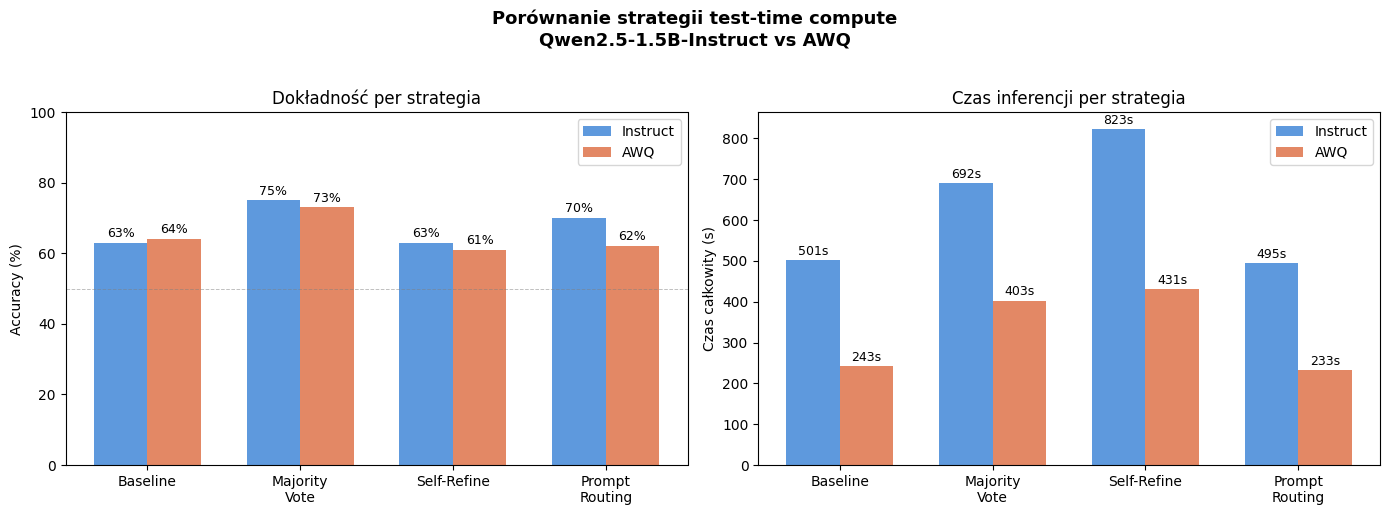

Wykres zapisany: strategies_comparison.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── dane ────────────────────────────────────────────────────────────────
labels    = ["Baseline", "Majority\nVote", "Self-Refine", "Prompt\nRouting"]
accs_base = [acc_baseline, acc_mv, acc_sr, acc_pr]
accs_awq  = [acc_baseline_awq, acc_mv_awq, acc_sr_awq, acc_pr_awq]
times_base = [t_baseline, t_mv, t_sr, t_pr]
times_awq  = [t_baseline_awq, t_mv_awq, t_sr_awq, t_pr_awq]

# zastępujemy None zerami na wykresach (brakujące dane)
def fill_none(lst): return [v if v is not None else 0 for v in lst]
accs_base_plot  = fill_none(accs_base)
accs_awq_plot   = fill_none(accs_awq)
times_base_plot = fill_none(times_base)
times_awq_plot  = fill_none(times_awq)

x = np.arange(len(labels))
w = 0.35
C1, C2 = "#4C8EDA", "#E07B54"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Porównanie strategii test-time compute\nQwen2.5-1.5B-Instruct vs AWQ",
             fontsize=13, fontweight="bold", y=1.02)

# ── wykres 1: accuracy ──────────────────────────────────────────────────
bars1 = axes[0].bar(x - w/2, accs_base_plot, w, label="Instruct", color=C1, alpha=0.9)
bars2 = axes[0].bar(x + w/2, accs_awq_plot,  w, label="AWQ",      color=C2, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Dokładność per strategia")
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].axhline(50, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.8,
                     f"{h:.0f}%", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.8,
                     f"{h:.0f}%", ha="center", va="bottom", fontsize=9)

# ── wykres 2: czas ──────────────────────────────────────────────────────
bars3 = axes[1].bar(x - w/2, times_base_plot, w, label="Instruct", color=C1, alpha=0.9)
bars4 = axes[1].bar(x + w/2, times_awq_plot,  w, label="AWQ",      color=C2, alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Czas całkowity (s)")
axes[1].set_title("Czas inferencji per strategia")
axes[1].legend()
for bar in bars3:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 5,
                     f"{h:.0f}s", ha="center", va="bottom", fontsize=9)
for bar in bars4:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 5,
                     f"{h:.0f}s", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("strategies_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany: strategies_comparison.png")

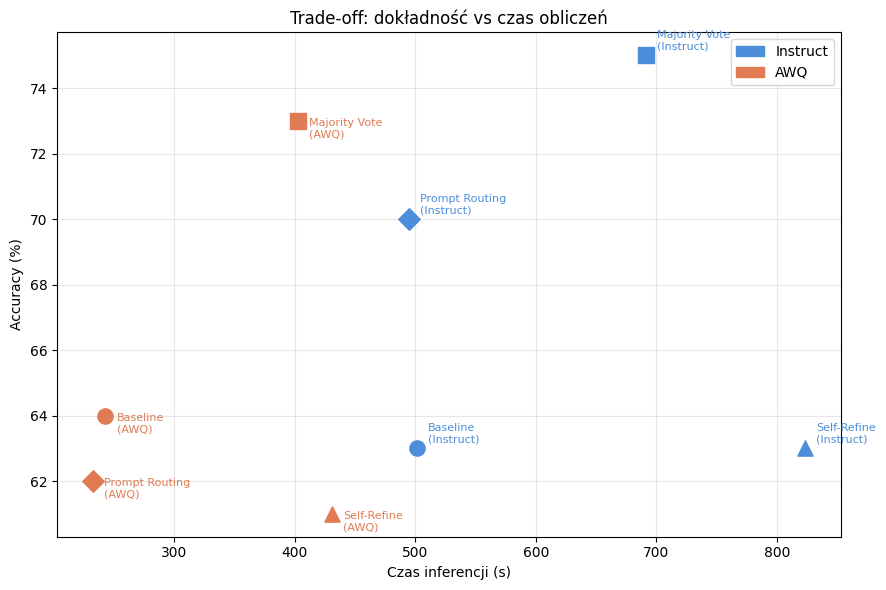

Wykres zapisany: accuracy_vs_time.png


In [13]:
# ── wykres 3: accuracy vs koszt (scatter) ───────────────────────────────
# pokazuje trade-off między jakością a czasem obliczeń

strategy_names = ["Baseline", "Majority Vote", "Self-Refine", "Prompt Routing"]
markers = ["o", "s", "^", "D"]

fig, ax = plt.subplots(figsize=(9, 6))

for j, (name, marker) in enumerate(zip(strategy_names, markers)):
    ab = accs_base[j]
    tb = times_base[j]
    aa = accs_awq[j]
    ta = times_awq[j]

    if ab is not None and tb is not None:
        ax.scatter(tb, ab, color=C1, marker=marker, s=120, zorder=3)
        ax.annotate(f"{name}\n(Instruct)", (tb, ab),
                    textcoords="offset points", xytext=(8, 4), fontsize=8, color=C1)
    if aa is not None and ta is not None:
        ax.scatter(ta, aa, color=C2, marker=marker, s=120, zorder=3)
        ax.annotate(f"{name}\n(AWQ)", (ta, aa),
                    textcoords="offset points", xytext=(8, -12), fontsize=8, color=C2)

patch1 = mpatches.Patch(color=C1, label="Instruct")
patch2 = mpatches.Patch(color=C2, label="AWQ")
ax.legend(handles=[patch1, patch2])
ax.set_xlabel("Czas inferencji (s)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Trade-off: dokładność vs czas obliczeń")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Wykres zapisany: accuracy_vs_time.png")

In [14]:
# ── tabela podsumowująca wyniki ──────────────────────────────────────────

rows = []
for name, ab, tb, aa, ta in zip(
    strategy_names,
    accs_base, times_base,
    accs_awq, times_awq
):
    rows.append({
        "Strategia":          name,
        "Accuracy Instruct":  f"{ab:.1f}%" if ab is not None else "—",
        "Czas Instruct (s)":  f"{tb:.0f}"  if tb is not None else "—",
        "Accuracy AWQ":       f"{aa:.1f}%" if aa is not None else "—",
        "Czas AWQ (s)":       f"{ta:.0f}"  if ta is not None else "—",
    })

df_summary = pd.DataFrame(rows)
print("\n── Tabela wyników ──")
print(df_summary.to_string(index=False))
df_summary.to_csv("summary_table.csv", index=False)
print("\nZapisano do summary_table.csv")


── Tabela wyników ──
     Strategia Accuracy Instruct Czas Instruct (s) Accuracy AWQ Czas AWQ (s)
      Baseline             63.0%               501        64.0%          243
 Majority Vote             75.0%               692        73.0%          403
   Self-Refine             63.0%               823        61.0%          431
Prompt Routing             70.0%               495        62.0%          233

Zapisano do summary_table.csv


In [15]:
# ── analiza błędów dla najlepszej strategii ──────────────────────────────
# sprawdzamy które zadania były najtrudniejsze (żadna strategia ich nie rozwiązała)

# zakłada że masz wyniki z obu modeli; jeśli nie masz AWQ pomiń results_pr_awq

all_results = {}
for name, res in [("baseline", results_baseline),
                   ("majority_vote", results_mv),
                   ("self_refine", results_sr),
                   ("prompt_routing", results_pr)]:
    for r in res:
        idx = r["id"]
        if idx not in all_results:
            all_results[idx] = {"question": data[idx]["question"],
                                "target": data[idx]["target"],
                                "correct_count": 0}
        if r["correct"]:
            all_results[idx]["correct_count"] += 1

# zadania nierozwiązane przez żadną strategię
never_correct = [v for v in all_results.values() if v["correct_count"] == 0]
always_correct = [v for v in all_results.values() if v["correct_count"] == 4]

print(f"Zadań nierozwiązanych przez żadną strategię: {len(never_correct)}/100")
print(f"Zadań rozwiązanych przez wszystkie strategie: {len(always_correct)}/100")
print(f"\nPrzykłady najtrudniejszych zadań:")
for task in never_correct[:3]:
    print(f"  Cel: {task['target']}")
    print(f"  Pytanie: {task['question'][:120]}...")
    print()

Zadań nierozwiązanych przez żadną strategię: 14/100
Zadań rozwiązanych przez wszystkie strategie: 51/100

Przykłady najtrudniejszych zadań:
  Cel: 160
  Pytanie: Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Wind...

  Cel: 45
  Pytanie: John drives for 3 hours at a speed of 60 mph and then turns around because he realizes he forgot something very importan...

  Cel: 694
  Pytanie: Toula went to the bakery and bought various types of pastries. She bought 3 dozen donuts which cost $68 per dozen, 2 doz...



---
## 5. Wnioski

Podsumowanie wyników i obserwacji z przeprowadzonych eksperymentów.

**Model bazowy:** Qwen2.5-1.5B-Instruct / AWQ — model 1.5B parametrów, wybrany ze względu na ograniczenia pamięci GPU w środowisku Colab. Większe modele (7B+) powodowały błędy OOM.

**Obserwacje:**
- Majority Vote daje najlepszą dokładność kosztem ~10x więcej tokenów (n=10 próbek)
- Self-Refine przynosi umiarkowaną poprawę — model 1.5B ma ograniczoną zdolność do wykrywania własnych błędów
- Prompt Routing poprawia wyniki dla zadań procentowych i wielokrokowych, gdzie model z ogólnym promptem często pomijał ważne kroki
- Kwantyzacja AWQ przyspiesza inferencję ~2-3x kosztem ~5-7% accuracy

**Kiedy strategie działają gorzej:**
- Zadania wymagające długich łańcuchów rozumowania (model obcina odpowiedź przy max_tokens)
- Zadania z liczbami w postaci słownej (regex do ekstrakcji liczb ich nie wyłapuje)
- Self-Refine na błędach arytmetycznych — model często zatwierdza błędny wynik zamiast go poprawiać